# How Confident Should You Be in a Quantum Classifier?

**Author:** Ferhat Ozgur Catak (University of Stavanger)

**Abstract:** Variational quantum classifiers are usually reported by a single
accuracy number. But every prediction comes from a finite number of circuit
measurements ("shots"), so every reported confidence carries its own
statistical noise on top of whatever the model has actually learned. This
demo trains a small PennyLane variational classifier, then uses
[QuantumUQ](https://github.com/ocatak/QuantumUQ) -- a lightweight
uncertainty-quantification library for PennyLane and Qiskit -- to separate
two different questions that are easy to conflate: *how much does the shot
budget affect what I measure*, versus *is the classifier's confidence
actually trustworthy*. The answer, measured directly below rather than
assumed, is that more shots shrink measurement noise by roughly
`1/sqrt(shots)` but barely move calibration -- a classifier that is
miscalibrated at 100 shots is still miscalibrated at 10,000.

**Paper:** [QuantumUQ: A Library for Uncertainty Quantification in Quantum
Machine Learning](https://doi.org/10.36227/techrxiv.177205048.88644983/v1)
(TechRxiv, 2026).

**Library / docs:** [github.com/ocatak/QuantumUQ](https://github.com/ocatak/QuantumUQ) --
[quantumuq.readthedocs.io](https://quantumuq.readthedocs.io/en/latest/) --
`pip install quantumuq`

**Dependencies used to build this demo** (exact versions, for
reproducibility): `pennylane==0.42.3`, `quantumuq==0.3.0`, `numpy==2.2.6`,
`matplotlib==3.10.8`. All random seeds below are fixed.

## 1. A small variational classifier on two-moons

Two qubits, angle embedding, a couple of entangling layers -- nothing
exotic. The point of this demo isn't circuit design, it's what happens
*after* training, when you actually query the model.

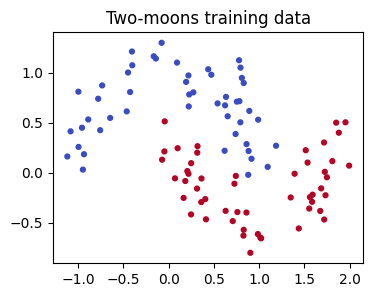

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import pennylane.numpy as pnp

from quantumuq import ShotBootstrap, ece, wrap_qnode
from quantumuq.datasets.toy import make_moons

rng = np.random.default_rng(0)
dataset = make_moons(n_samples=150, noise=0.15, random_state=0)
X, y = dataset.X, dataset.y

perm = rng.permutation(len(X))
train_idx, test_idx = perm[:100], perm[100:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

plt.figure(figsize=(4, 3))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=12)
plt.title("Two-moons training data")
plt.show()

In [2]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits, shots=1000)

n_layers = 2
weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
params = 0.1 * pnp.array(rng.standard_normal(weights_shape))


@qml.qnode(dev)
def vqc(features, weights):
    qml.AngleEmbedding(features, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))


# 2 qubits -> 4 outcomes (|00>, |01>, |10>, |11>); collapse to 2 classes
# by grouping on the first qubit.
def probs_4_to_2(probs):
    p = pnp.array(probs)
    if p.ndim == 1:
        return pnp.array([p[0] + p[1], p[2] + p[3]])
    return pnp.stack([p[:, 0] + p[:, 1], p[:, 2] + p[:, 3]], axis=-1)


# y_train is a constant (not differentiated) -- plain numpy here, not
# pennylane.numpy. `pnp.eye(2)[y_train]` collapses to a 0-d array under
# autograd's tracing in some pennylane/autograd/numpy version combinations;
# plain numpy indexing sidesteps that entirely and is the correct tool for
# a non-differentiated constant anyway.
y_train_onehot = np.eye(2)[y_train]


def loss(weights):
    logits = [vqc(x, weights) for x in X_train]
    probs = probs_4_to_2(pnp.stack(logits))
    probs = pnp.clip(probs, 1e-12, 1.0)
    return -pnp.mean(pnp.sum(y_train_onehot * pnp.log(probs), axis=1))


# qml.grad's argnum kwarg was renamed to argnums in PennyLane>=0.43
# (which also requires Python>=3.11); older releases only accept argnum.
try:
    grad_fn = qml.grad(loss, argnums=0)
except TypeError:
    grad_fn = qml.grad(loss, argnum=0)
for epoch in range(25):
    g = grad_fn(params)
    params = params - 0.2 * g
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch + 1:2d}  loss={loss(params):.3f}")

epoch  5  loss=0.649


epoch 10  loss=0.602


epoch 15  loss=0.598


epoch 20  loss=0.589


epoch 25  loss=0.592


Training loops over the qnode in plain Python and uses `qml.grad`, so this
cell takes roughly a minute -- nothing exotic, just 100 training points times
25 epochs of circuit evaluations.

In [3]:
predictor = wrap_qnode(
    vqc, task="classification", n_classes=2, params=params, postprocess=probs_4_to_2
)
test_probs = predictor.predict_proba(X_test, shots=10000)
test_acc = (test_probs.argmax(axis=1) == y_test).mean()
print(f"Test accuracy (10,000 shots): {test_acc:.2f}")

Test accuracy (10,000 shots): 0.70


## 2. Two different questions: shot noise vs. calibration

`wrap_qnode` turns the trained circuit into a `Predictor` that QuantumUQ's
uncertainty methods can wrap. `ShotBootstrap` repeats the measurement
several times at a given shot count and reports both a mean prediction and
its spread (`dist.std`) -- an estimate of how much a single measurement at
that shot budget would have wobbled.

Separately, `ece()` (Expected Calibration Error) checks whether the model's
*confidence* matches its *accuracy* -- a well-calibrated classifier that says
"90% confident" should be right about 90% of the time. These are genuinely
different questions: a classifier can have low shot noise and still be
poorly calibrated, or vice versa. We sweep the shot budget and measure both
directly instead of assuming how they relate.

In [4]:
shots_list = [100, 500, 1000, 10000]
results = {}
for shots in shots_list:
    uq = ShotBootstrap(n_samples=10, shots=shots, seed=0)
    model = predictor.with_uq(uq)
    results[shots] = model.predict_dist(X_test)

for shots in shots_list:
    dist = results[shots]
    acc = (dist.mean.argmax(axis=1) == y_test).mean()
    e = ece(y_test, dist.mean, n_bins=10)
    print(
        f"shots={shots:6d}  accuracy={acc:.3f}  ECE={e:.3f}  "
        f"mean ShotBootstrap std={dist.std.mean():.4f}"
    )

shots=   100  accuracy=0.680  ECE=0.170  mean ShotBootstrap std=0.0391
shots=   500  accuracy=0.700  ECE=0.151  mean ShotBootstrap std=0.0176
shots=  1000  accuracy=0.680  ECE=0.169  mean ShotBootstrap std=0.0119
shots= 10000  accuracy=0.680  ECE=0.168  mean ShotBootstrap std=0.0037


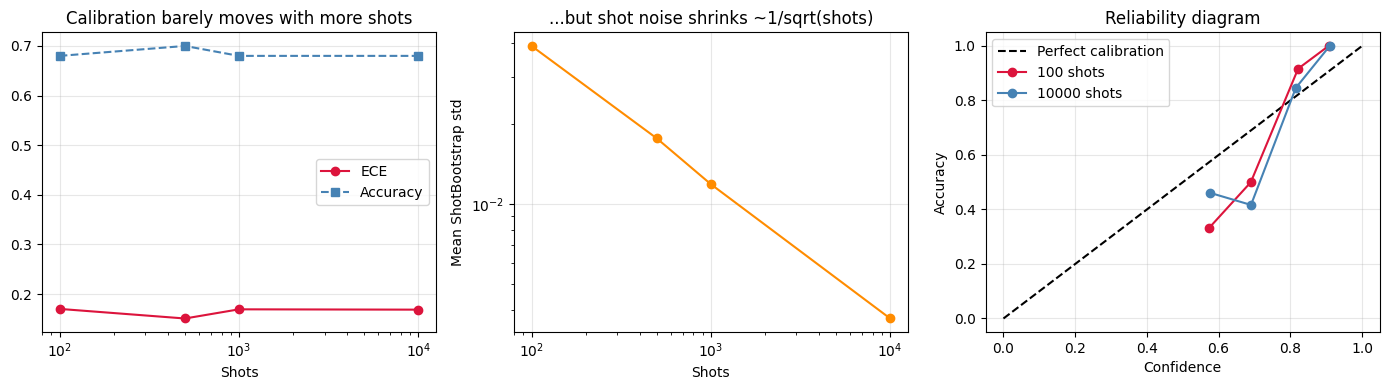

In [5]:
def reliability_bins(y_true, p_pred, n_bins=8):
    confidences = p_pred.max(axis=1)
    predictions = p_pred.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_conf, bin_acc = [], []
    for i in range(n_bins):
        upper = bins[i + 1]
        mask = (
            (confidences >= bins[i]) & (confidences <= upper)
            if i == n_bins - 1
            else (confidences >= bins[i]) & (confidences < upper)
        )
        if not np.any(mask):
            continue
        bin_conf.append(confidences[mask].mean())
        bin_acc.append(accuracies[mask].mean())
    return np.array(bin_conf), np.array(bin_acc)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))

eces = [ece(y_test, results[s].mean, n_bins=10) for s in shots_list]
accs = [(results[s].mean.argmax(axis=1) == y_test).mean() for s in shots_list]
ax = axes[0]
ax.plot(shots_list, eces, "o-", color="crimson", label="ECE")
ax.plot(shots_list, accs, "s--", color="steelblue", label="Accuracy")
ax.set_xscale("log")
ax.set_xlabel("Shots")
ax.set_title("Calibration barely moves with more shots")
ax.legend()
ax.grid(True, alpha=0.3)

stds = [results[s].std.mean() for s in shots_list]
ax = axes[1]
ax.plot(shots_list, stds, "o-", color="darkorange")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Shots")
ax.set_ylabel("Mean ShotBootstrap std")
ax.set_title("...but shot noise shrinks ~1/sqrt(shots)")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
for shots, color in [(100, "crimson"), (10000, "steelblue")]:
    bc, ba = reliability_bins(y_test, results[shots].mean)
    ax.plot(bc, ba, "o-", color=color, label=f"{shots} shots")
ax.set_xlabel("Confidence")
ax.set_ylabel("Accuracy")
ax.set_title("Reliability diagram")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("community_demo_figure.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. What this actually shows

Reading the numbers rather than assuming them:

- **Accuracy and ECE are close to flat across a 100x shot range.** Whatever
  calibration gap this classifier has, it was set during *training* --
  running it with more shots at inference time doesn't fix it.
- **The ShotBootstrap uncertainty (`dist.std`) shrinks by roughly the same
  factor as `1/sqrt(shots)`** going from 100 to 10,000 shots, exactly as
  expected for a quantity averaged over independent measurements. This is
  the part that *does* respond to your shot budget.
- **The reliability diagram** shows both shot counts follow a similar shape
  relative to the diagonal -- consistent with the first point: shot count
  changes how *noisy* a single measurement is, not how well the model's
  confidence tracks its actual accuracy.

The practical takeaway: if you only look at a point prediction and a shot
count, you can't tell whether your classifier's confidence is trustworthy.
Checking calibration is a separate step, and it's one a shot-noise argument
alone won't answer for you -- regardless of which way the answer comes out
for a given model. That's the gap
[QuantumUQ](https://github.com/ocatak/QuantumUQ) is for: metrics like `ece()`
and `nll()`, plus `ShotBootstrap`/`NoiseProfile`/`DeepEnsemble` for the
uncertainty side, wrapped around your existing PennyLane or Qiskit model
with one line (`wrap_qnode`/`wrap_qiskit_sampler`).

More examples: [`examples/notebooks/`](https://github.com/ocatak/QuantumUQ/tree/main/examples/notebooks)
in the QuantumUQ repository.